In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

In [5]:
# 1. LOAD DATASET


df = pd.read_csv("C:/Users/LENOVO/Downloads/Bank authentication/BankNoteAuthentication.csv")
print(df.head())

print("\nDATASET SHAPE:", df.shape)

print("\nMISSING VALUES")
print(df.isnull().sum())

# Rename columns
df.columns = ["variance", "skewness", "curtosis", "entropy", "class"]

print("\nCLASS DISTRIBUTION")
print(df["class"].value_counts())


   variance  skewness  curtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

DATASET SHAPE: (1372, 5)

MISSING VALUES
variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

CLASS DISTRIBUTION
class
0    762
1    610
Name: count, dtype: int64


In [6]:
# 2. DATA PREPROCESSING

X = df.drop("class", axis=1)
y = df["class"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Standardization completed.")


Training Samples: 1097
Testing Samples: 275
Standardization completed.


In [9]:
#3. NAIVE BAYES


nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

y_pred_nb = nb.predict(X_test_scaled)

# Metrics
cm_nb = confusion_matrix(y_test, y_pred_nb)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(
    y_test, y_pred_nb, average="weighted"
)
recall_nb = recall_score(
    y_test, y_pred_nb, average="weighted"
)
f1_nb = f1_score(
    y_test, y_pred_nb, average="weighted"
)

print("\n========================================")
print("NAIVE BAYES RESULTS")
print("========================================")

print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1 Score :", round(f1_nb, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("Confusion Matrix:")
print(cm_nb)


NAIVE BAYES RESULTS
Accuracy : 0.8582
Precision: 0.858
Recall   : 0.8582
F1 Score : 0.858

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87       153
           1       0.85      0.83      0.84       122

    accuracy                           0.86       275
   macro avg       0.86      0.86      0.86       275
weighted avg       0.86      0.86      0.86       275

Confusion Matrix:
[[135  18]
 [ 21 101]]


In [10]:
# 4. KNN - FIND BEST K


k_values = range(1, 21)
k_accuracies = []

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, prediction)

    k_accuracies.append(accuracy)

best_k = k_values[np.argmax(k_accuracies)]

print("\n========================================")
print("KNN K-VALUE TUNING")
print("========================================")

print("Best K:", best_k)
print("Best Accuracy:", round(max(k_accuracies), 4))


KNN K-VALUE TUNING
Best K: 1
Best Accuracy: 1.0


In [11]:
# 5. FINAL KNN MODEL


knn = KNeighborsClassifier(n_neighbors=best_k)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

# Metrics
cm_knn = confusion_matrix(y_test, y_pred_knn)

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(
    y_test, y_pred_knn, average="weighted"
)
recall_knn = recall_score(
    y_test, y_pred_knn, average="weighted"
)
f1_knn = f1_score(
    y_test, y_pred_knn, average="weighted"
)

print("\n========================================")
print("KNN RESULTS")
print("========================================")

print("Best K   :", best_k)
print("Accuracy :", round(accuracy_knn, 4))
print("Precision:", round(precision_knn, 4))
print("Recall   :", round(recall_knn, 4))
print("F1 Score :", round(f1_knn, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("Confusion Matrix:")
print(cm_knn)



KNN RESULTS
Best K   : 1
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       122

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275

Confusion Matrix:
[[153   0]
 [  0 122]]


In [13]:
import os
os.environ["OMP_NUM_THREADS"] = "6"

In [14]:
# 6. K-MEANS CLUSTERING


scaler_kmeans = StandardScaler()

X_scaled = scaler_kmeans.fit_transform(X)

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

# Cluster centers
print("\n========================================")
print("K-MEANS RESULTS")
print("========================================")

print("\nCluster Centers:")
print(
    pd.DataFrame(
        kmeans.cluster_centers_,
        columns=X.columns
    )
)

print("\nWCSS / Inertia:")
print(round(kmeans.inertia_, 4))

# Silhouette Score
silhouette = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:",
      round(silhouette, 4))

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(



K-MEANS RESULTS

Cluster Centers:
   variance  skewness  curtosis   entropy
0  0.046300  0.808792 -0.690054 -0.683669
1 -0.042919 -0.749723  0.639657  0.633738

WCSS / Inertia:
3453.2919

Silhouette Score: 0.3291


In [15]:
# 7. MAP K-MEANS CLUSTERS TO ACTUAL CLASSES


accuracy_1 = accuracy_score(y, clusters)
accuracy_2 = accuracy_score(y, 1 - clusters)

if accuracy_1 >= accuracy_2:
    kmeans_pred = clusters
else:
    kmeans_pred = 1 - clusters

# Metrics
cm_kmeans = confusion_matrix(y, kmeans_pred)

accuracy_kmeans = accuracy_score(y, kmeans_pred)

precision_kmeans = precision_score(
    y, kmeans_pred, average="weighted"
)

recall_kmeans = recall_score(
    y, kmeans_pred, average="weighted"
)

f1_kmeans = f1_score(
    y, kmeans_pred, average="weighted"
)

ari = adjusted_rand_score(y, clusters)

nmi = normalized_mutual_info_score(y, clusters)

print("\nMapped Accuracy :", round(accuracy_kmeans, 4))
print("Precision       :", round(precision_kmeans, 4))
print("Recall          :", round(recall_kmeans, 4))
print("F1 Score        :", round(f1_kmeans, 4))
print("ARI             :", round(ari, 4))
print("NMI             :", round(nmi, 4))

print("\nConfusion Matrix:")
print(cm_kmeans)


Mapped Accuracy : 0.559
Precision       : 0.5675
Recall          : 0.559
F1 Score        : 0.5602
ARI             : 0.0132
NMI             : 0.011

Confusion Matrix:
[[409 353]
 [252 358]]


In [16]:
# 8. FINAL COMPARISON TABLE


results = pd.DataFrame({

    "Algorithm": [
        "Naive Bayes",
        "KNN",
        "K-Means"
    ],

    "Accuracy": [
        accuracy_nb,
        accuracy_knn,
        accuracy_kmeans
    ],

    "Precision": [
        precision_nb,
        precision_knn,
        precision_kmeans
    ],

    "Recall": [
        recall_nb,
        recall_knn,
        recall_kmeans
    ],

    "F1 Score": [
        f1_nb,
        f1_knn,
        f1_kmeans
    ]
})

print("\n========================================")
print("FINAL COMPARISON")
print("========================================")

print(results.round(4).to_string(index=False))

# Percentage table
percentage_results = results.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:
    percentage_results[column] = (
        percentage_results[column] * 100
    ).round(2)

print("\nRESULTS IN PERCENTAGE")
print(percentage_results.to_string(index=False))


FINAL COMPARISON
  Algorithm  Accuracy  Precision  Recall  F1 Score
Naive Bayes    0.8582     0.8580  0.8582    0.8580
        KNN    1.0000     1.0000  1.0000    1.0000
    K-Means    0.5590     0.5675  0.5590    0.5602

RESULTS IN PERCENTAGE
  Algorithm  Accuracy  Precision  Recall  F1 Score
Naive Bayes     85.82      85.80   85.82     85.80
        KNN    100.00     100.00  100.00    100.00
    K-Means     55.90      56.75   55.90     56.02



BEST ALGORITHM
Best Algorithm: KNN
Highest F1 Score: 1.0


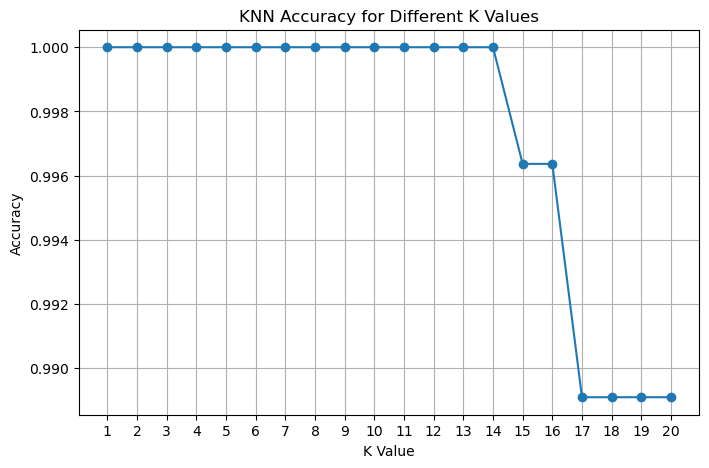

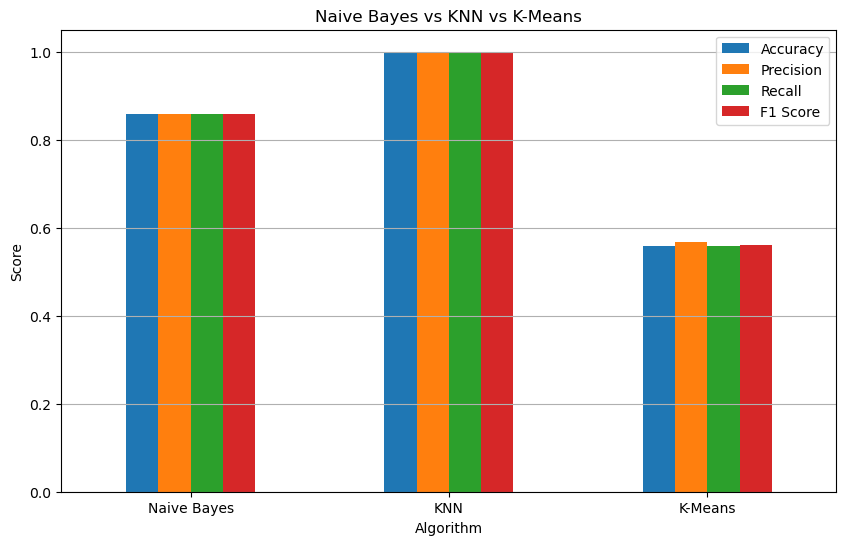

In [17]:
# 9. FIND BEST ALGORITHM


best_algorithm = results.loc[
    results["F1 Score"].idxmax(),
    "Algorithm"
]

best_f1 = results["F1 Score"].max()

print("\n========================================")
print("BEST ALGORITHM")
print("========================================")

print("Best Algorithm:", best_algorithm)
print("Highest F1 Score:", round(best_f1, 4))

# ============================================================
# 10. GRAPHS
# ============================================================

# KNN graph
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    k_accuracies,
    marker="o"
)

plt.title("KNN Accuracy for Different K Values")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.xticks(list(k_values))
plt.grid()

plt.show()

# Final comparison graph
results.set_index("Algorithm").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Naive Bayes vs KNN vs K-Means"
)

plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

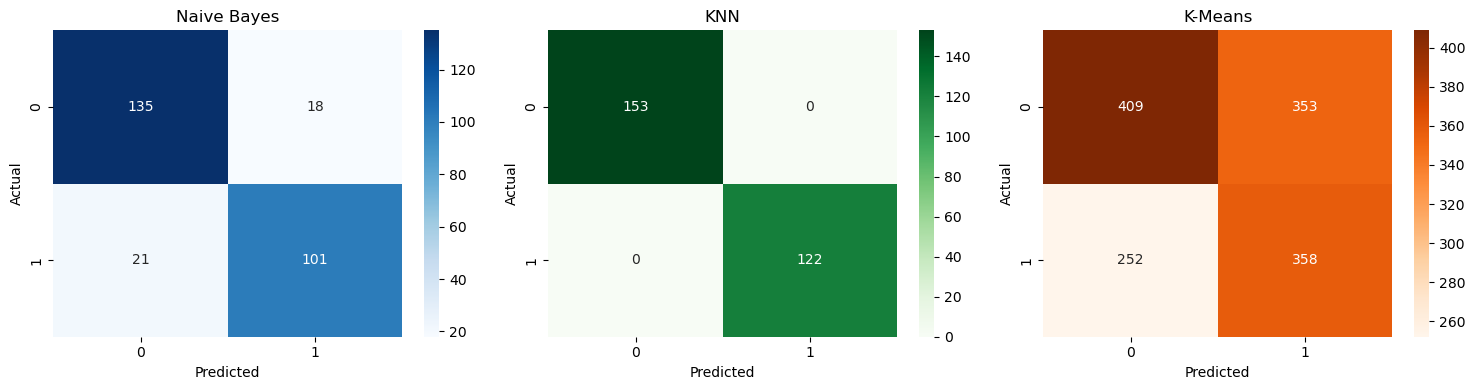

In [18]:
# 11. CONFUSION MATRICES


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0]
)

axes[0].set_title("Naive Bayes")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[1]
)

axes[1].set_title("KNN")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

sns.heatmap(
    cm_kmeans,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=axes[2]
)

axes[2].set_title("K-Means")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [19]:
# 12. FINAL CONCLUSION


print("\n========================================")
print("CONCLUSION")
print("========================================")

print(
    f"{best_algorithm} achieved the highest F1 Score "
    f"of {best_f1:.4f} among the three algorithms."
)

print(
    f"Therefore, {best_algorithm} is considered the "
    "best-performing algorithm for this dataset based "
    "on the obtained classification results."
)

print(
    "\nNaive Bayes is simple and computationally fast "
    "and works using probability."
)

print(
    "KNN classifies a banknote by comparing it with "
    "nearby data points and is affected by the choice of K."
)

print(
    "K-Means is an unsupervised algorithm. It groups "
    "banknotes into two clusters without using class "
    "labels during training."
)

print(
    "\nThe final algorithm should be selected based on "
    "the actual Accuracy, Precision, Recall and F1 Score "
    "obtained from the experiment."
)


CONCLUSION
KNN achieved the highest F1 Score of 1.0000 among the three algorithms.
Therefore, KNN is considered the best-performing algorithm for this dataset based on the obtained classification results.

Naive Bayes is simple and computationally fast and works using probability.
KNN classifies a banknote by comparing it with nearby data points and is affected by the choice of K.
K-Means is an unsupervised algorithm. It groups banknotes into two clusters without using class labels during training.

The final algorithm should be selected based on the actual Accuracy, Precision, Recall and F1 Score obtained from the experiment.
